In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pyprojroot import find_root, has_file
from sklearn.datasets import fetch_california_housing

# 1. Load the raw California Housing dataset from sklearn
housing = fetch_california_housing(as_frame=True)
features = housing.data
target = housing.target.to_frame(name="MedHouseValue")

# 2. Combine features and target into a single DataFrame for processing
df = pd.concat([features, target], axis=1)
data = df.copy()  # Create a working copy to preserve the original merged data

# 3. Dynamic root resolution: Locate the 'P1' project root folder via .gitignore
ROOT = find_root(has_file(".gitignore"))
path = ROOT / "dataset" / "california_housing.csv"

# 4. Handle directory safety and persist data to disk
csv_path = Path(path)

# Ensure the 'dataset/' subfolder exists; create it dynamically if missing
csv_path.parent.mkdir(parents=True, exist_ok=True)

# Cache the DataFrame to CSV only if it hasn't been saved yet to avoid redundant writes
if not csv_path.exists():
    df.to_csv(csv_path, index=False)

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Inspect the total size of the combined dataset
total_rows = len(df)
print(f"Total rows in the dataset: {total_rows}")

# 2. Isolate predictor variables (X) from the dependent target variable (Y)
X = df.drop('MedHouseValue', axis=1)
Y = df['MedHouseValue']

# 3. Partition data into training (70%) and testing (30%) subsets
# 'random_state=42' ensures the shuffle split is perfectly reproducible across runs
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
# 4. Verify the distribution of rows across both subsets
print(f"Number of rows in the training set: {len(X_train)}")
print(f"Number of rows in the testing set: {len(X_test)}")

# 5. Recombine features and targets into separate DataFrames for exploration/saving
train_df = pd.concat([X_train, Y_train], axis=1)
test_df = pd.concat([X_test, Y_test], axis=1)

Total rows in the dataset: 20640
Number of rows in the training set: 14448
Number of rows in the testing set: 6192


# 1. Data Inspection
### This section performs initial exploratory data analysis (EDA) on the dataset to understand its structure and characteristics.

**Operations:**

- **df.head()**: Displays the first few rows of the dataset
    - *Importance*: Provides a quick visual overview of the data format and sample values
    - *When to use*: At the start of analysis to verify data loaded correctly and understand column names/types

- **df.info()**: Shows data types and non-null value counts for each column
    - *Importance*: Identifies missing values and data type inconsistencies that may require preprocessing
    - *When to use*: When checking for data quality issues and memory usage before modeling

- **df.shape**: Returns the number of rows and columns in the dataset
    - *Importance*: Essential for understanding dataset size and planning train/validation/test splits
    - *When to use*: When determining computational feasibility and designing data partitioning strategy

- **df.nunique()**: Counts distinct values in each column
    - *Importance*: Helps identify categorical vs continuous features and detects potential outliers/errors
    - *When to use*: When determining which features need encoding and which are already numeric

- **df.describe()**: Generates descriptive statistics (mean, std, min, max, quartiles)
    - *Importance*: Reveals data distribution, range, and potential outliers/anomalies
    - *When to use*: When understanding feature scales, distributions, and whether normalization/scaling is needed

In [5]:
# View data to see the first 5 rows
train_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02,1.93800
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09,1.69700
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14,2.59800
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00,1.36100
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45,5.00001


In [6]:
# To check the datatype and the no. of filled values in each feature
train_df.info()

<class 'pandas.DataFrame'>
Index: 14448 entries, 7061 to 15795
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         14448 non-null  float64
 1   HouseAge       14448 non-null  float64
 2   AveRooms       14448 non-null  float64
 3   AveBedrms      14448 non-null  float64
 4   Population     14448 non-null  float64
 5   AveOccup       14448 non-null  float64
 6   Latitude       14448 non-null  float64
 7   Longitude      14448 non-null  float64
 8   MedHouseValue  14448 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB


In [7]:
# To check the no. of row and columns. Useful for train/val/test split of data
train_df.shape

(14448, 9)

In [8]:
# To see all the distinct no. of values in each feature. Useful to identify categorical features
train_df.nunique()

MedInc            9851
HouseAge            52
AveRooms         13802
AveBedrms        10758
Population        3495
AveOccup         13479
Latitude           826
Longitude          815
MedHouseValue     3552
dtype: int64

In [9]:
# Gives basic statistics of each feature.
train_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,3.876892,28.575374,5.438125,1.098033,1427.927326,3.119236,35.650669,-119.584102,2.069240
std,1.904908,12.613634,2.453569,0.447498,1140.225190,12.373636,2.135742,2.002930,1.157492
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.567225,18.000000,4.448928,1.006783,791.000000,2.430380,33.940000,-121.800000,1.193000
50%,3.539100,29.000000,5.232422,1.049492,1168.000000,2.817147,34.270000,-118.510000,1.793000
75%,4.758075,37.000000,6.060692,1.100328,1727.000000,3.279135,37.720000,-118.010000,2.646000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
train_df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

# 2. Column-wise Analysis

This section looks at each column one by one to understand the data better.

### Goals
- Check basic statistics for each column.
- Find the center, spread, and shape of the data.
- Detect outliers.
- Plot distributions to see how the values are spread.

### What each check tells us
- **`df.head()`**: Shows a few rows so we can quickly inspect the data.
- **`df.info()`**: Shows data types and missing values.
- **`df.shape`**: Shows how many rows and columns the dataset has.
- **`df.nunique()`**: Shows how many unique values each column has.
- **`df.describe()`**: Gives summary statistics such as:
    - **mean** and **median** for center;
    - **std** for spread;
    - **min** and **max** for range;
    - **Q1** and **Q3** for quartiles.
- **Typical range (`mean ± std`)**: Gives a quick idea of where most values are.
- **IQR and outlier limits**:
    - `IQR = Q3 - Q1`
    - `lower_limit = Q1 - 1.5 × IQR`
    - `upper_limit = Q3 + 1.5 × IQR`
    - Count values outside these limits to find outliers.
- **Missing values**: Use `df.isnull().sum()` to see if any column has missing data.
- **Distribution shape**:
    - If mean and median are close, the data is roughly symmetric.
    - If mean is larger than median, the data is likely right-skewed.
    - If mean is smaller than median, the data is likely left-skewed.
- **KDE plots**: Help visualize the shape of each column’s distribution.

### Why this matters
- Many outliers or strong skew may need transformation or robust methods.
- Missing values may need imputation or removal.
- Very few unique values may mean a feature is categorical or not very useful.

In [22]:

def analyze_column(dataframe, column_name):
    """
    Performs and prints a detailed statistical analysis for a given column,
    including central tendency, IQR outlier detection, and skewness estimation.
    """
    print(f"--- Analysis for: {column_name} ---")
    column = dataframe[column_name]
    
    # 1. Output summary statistics (count, mean, std, min, quartiles, max)
    print("Training dataset:")
    print(column.describe())
    print()

    # 2. Implement Tukey's Fences method for outlier detection
    q1 = column.quantile(0.25)   # 25th percentile (1st quartile)
    q3 = column.quantile(0.75)   # 75th percentile (3rd quartile)
    iqr = q3 - q1                # Interquartile Range
    upper_limit = q3 + 1.5 * iqr # Upper threshold for severe deviations
    
    # Count how many data points breach the upper boundary
    above_upper = (column > upper_limit).sum()
    
    print(f"Interquartile Range (IQR): {iqr}")
    print(f"Outliers above upper limit: {above_upper}")
    
    # FIX: Dynamically calculate percentage relative to the active dataframe
    outlier_percentage = (above_upper / len(column)) * 100
    print(f"Outlier percentage for {column_name}: {outlier_percentage:.2f}%")
    
    # 3. Estimate skewness direction geometrically by comparing mean vs median
    mean = column.mean()
    median = column.median()
    
    # Use relative/absolute tolerances to check if mean and median are roughly equal
    if np.isclose(mean, median, rtol=0.05, atol=0.05):
        print("Distribution shape: Likely symmetric")
    elif mean > median:
        print("Distribution shape: Likely right-skewed (positive skew)")
    else:
        print("Distribution shape: Likely left-skewed (negative skew)")
        
    print("-" * (20 + len(column_name)))
    print()

# 4. Batch execute the analysis across target features
columns_to_analyze = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseValue']
for col in columns_to_analyze:
    analyze_column(train_df, col)

--- Analysis for: MedInc ---
Training dataset:
count    14448.000000
mean         3.876892
std          1.904908
min          0.499900
25%          2.567225
50%          3.539100
75%          4.758075
max         15.000100
Name: MedInc, dtype: float64

Interquartile Range (IQR): 2.1908499999999997
Outliers above upper limit: 475
Outlier percentage for MedInc: 3.29%
Distribution shape: Likely right-skewed (positive skew)
--------------------------

--- Analysis for: HouseAge ---
Training dataset:
count    14448.000000
mean        28.575374
std         12.613634
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64

Interquartile Range (IQR): 19.0
Outliers above upper limit: 0
Outlier percentage for HouseAge: 0.00%
Distribution shape: Likely symmetric
----------------------------

--- Analysis for: AveRooms ---
Training dataset:
count    14448.000000
mean         5.438125
std          2.453569
min     

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Z-score StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler exclusively on the training features to calculate mean and variance
scaler.fit(X_train)

# 3. Transform the data and convert back to DataFrames
# Passing only 'columns' ensures feature headers are kept, while the index naturally resets to 0, 1, 2...
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 4. Alias the scaled training features for downstream visualization/modeling
train_df_scaled = X_train_scaled

# 5. Inspect the top 5 rows to verify a clean, 0-indexed layout
train_df_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.133506,0.509357,0.181060,-0.273850,-0.184117,-0.010825,-0.805682,0.780934
1,-0.532218,-0.679873,-0.422630,-0.047868,-0.376191,-0.089316,-1.339473,1.245270
2,0.170990,-0.362745,0.073128,-0.242600,-0.611240,-0.044800,-0.496645,-0.277552
3,-0.402916,-1.155565,0.175848,-0.008560,-0.987495,-0.075230,1.690024,-0.706938
4,-0.299285,1.857152,-0.259598,-0.070993,0.086015,-0.066357,0.992350,-1.430902


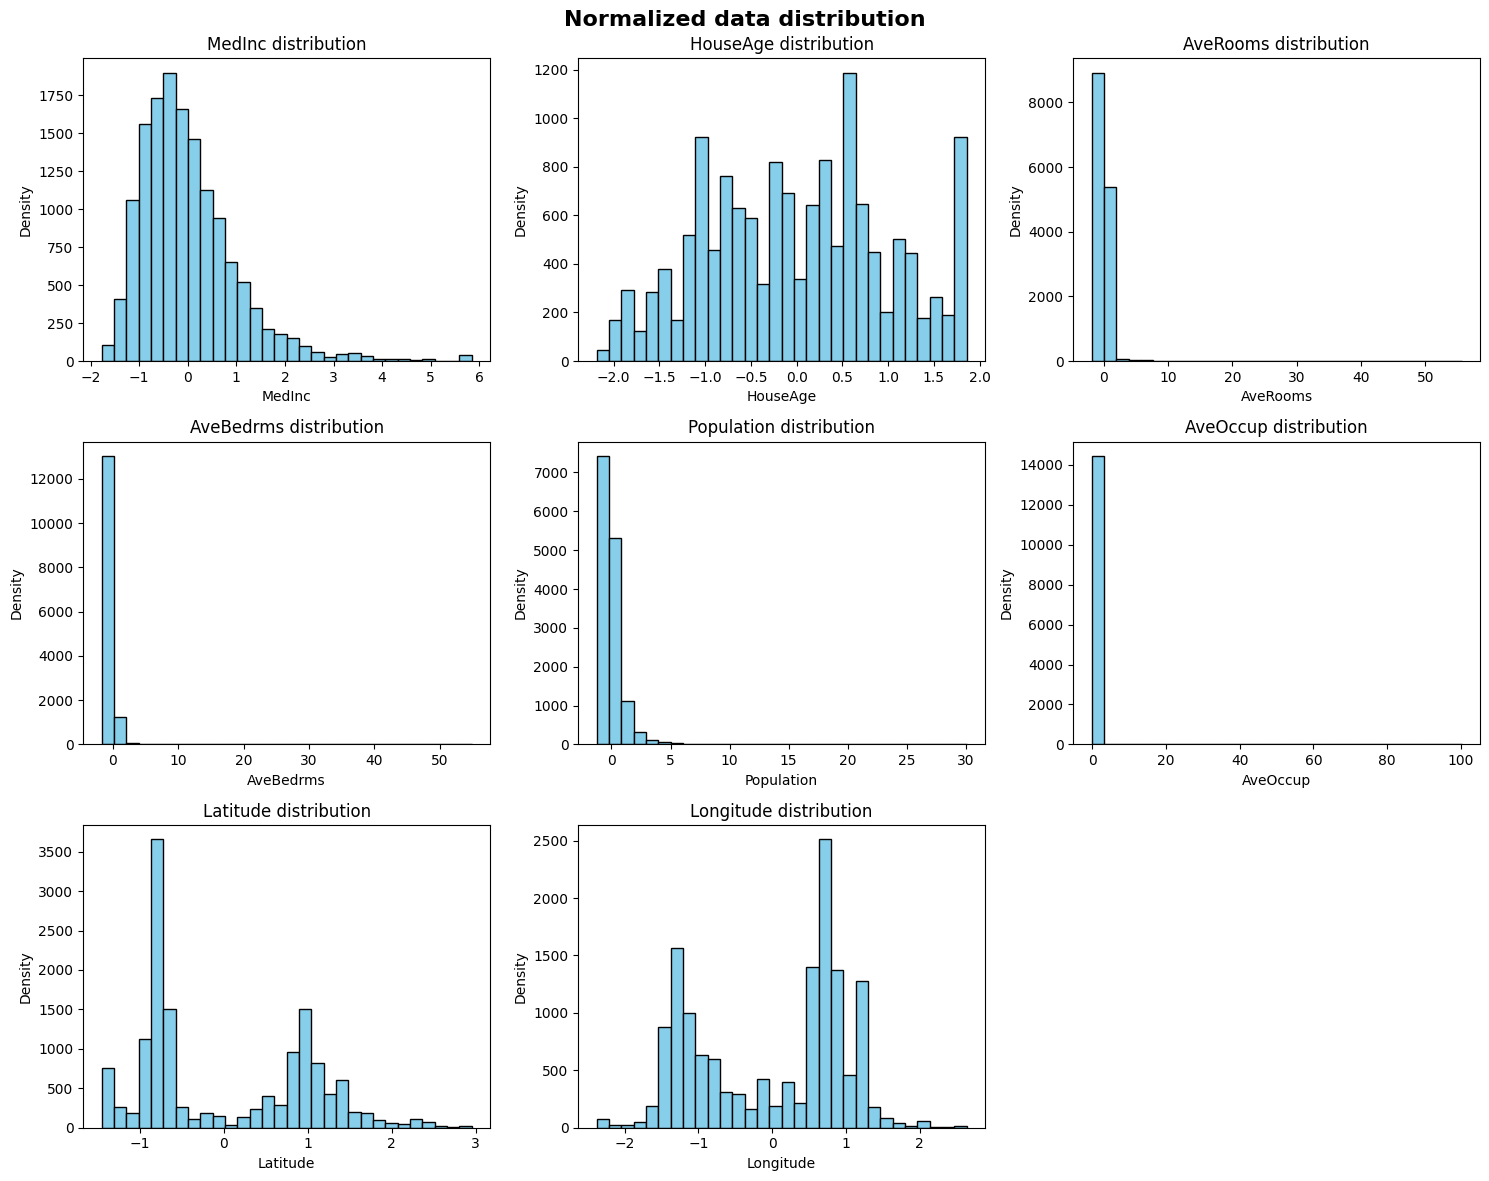

In [13]:
import math

# 1. Define the features to visualize from your scaled DataFrame
columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# 2. Dynamically calculate grid proportions (e.g., 3 columns wide, rows scale automatically)
n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

# 3. Initialize the grid figure canvas and flatten the 2D axes matrix to a 1D array
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows))
fig.suptitle("Normalized data distribution", fontsize=16, fontweight='bold', y=0.98)
axes_flat = axes.flatten()

# 4. Iterate through your columns and axes simultaneously using zip()
for col, ax in zip(columns, axes_flat):
    # Plot the scaled data as a histogram
    ax.hist(train_df_scaled[col], bins=30, color="skyblue", edgecolor="black")
    
    # Apply descriptive labels and titles per subplot
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# 5. Clean up the grid by turning off visibility for any trailing, unused axes
for ax in axes_flat[len(columns):]:
    ax.set_visible(False)

# 6. Optimize spatial layout and export the final dashboard to your plots directory
plt.tight_layout()
plt.savefig(ROOT / "plots" / "training_data_distribution_normalized.png", dpi=300)
plt.show()

In [25]:
from pathlib import Path

def save_df(df, path):
    """
    Safely exports a pandas DataFrame to a CSV file.
    
    Automatically creates any missing parent directories and protects 
    against accidentally overwriting existing data.
    """
    csv_path = Path(path)
    
    # 1. Ensure the destination folder tree exists; create it dynamically if missing
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    
# 2. Idempotency Check: Save only if the file does not already exist on disk
    # Export with standard UTF-8 encoding and suppress the pandas index column
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"DataFrame saved successfully to {csv_path}")


In [26]:
# 1. Establish the target directory for model training assets
savepoint = ROOT / "training"

Y_train = Y_train.reset_index(drop = True)
Y_test = Y_test.reset_index(drop = True)
# 2. Persist scaled features and raw targets cleanly using pathlib's / operator
save_df(X_train_scaled, savepoint / "X_train_scaled.csv")
save_df(Y_train,        savepoint / "Y_train.csv")
save_df(X_test_scaled,  savepoint / "X_test_scaled.csv")
save_df(Y_test,         savepoint / "Y_test.csv")

DataFrame saved successfully to d:\Dev\projects\p1\training\X_train_scaled.csv
DataFrame saved successfully to d:\Dev\projects\p1\training\Y_train.csv
DataFrame saved successfully to d:\Dev\projects\p1\training\X_test_scaled.csv
DataFrame saved successfully to d:\Dev\projects\p1\training\Y_test.csv


In [27]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.133506,0.509357,0.181060,-0.273850,-0.184117,-0.010825,-0.805682,0.780934
1,-0.532218,-0.679873,-0.422630,-0.047868,-0.376191,-0.089316,-1.339473,1.245270
2,0.170990,-0.362745,0.073128,-0.242600,-0.611240,-0.044800,-0.496645,-0.277552
3,-0.402916,-1.155565,0.175848,-0.008560,-0.987495,-0.075230,1.690024,-0.706938
4,-0.299285,1.857152,-0.259598,-0.070993,0.086015,-0.066357,0.992350,-1.430902


In [28]:
X_test_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-1.152689,-0.283463,-0.507818,-0.169278,-0.031510,0.061278,0.191664,0.286641
1,-0.706406,0.112947,-0.162520,0.213327,0.120220,-0.035516,-0.239115,0.061963
2,-0.208307,1.857152,-0.595467,0.196308,-0.103428,-0.142154,1.006397,-1.425909
3,0.976831,-0.917719,0.295707,-0.173931,0.243007,0.026283,-0.641799,0.431434
4,-0.079740,0.430075,0.022362,-0.156421,-0.320060,-0.051368,0.453877,-1.171273


In [29]:
Y_train.head()

0    1.93800
1    1.69700
2    2.59800
3    1.36100
4    5.00001
Name: MedHouseValue, dtype: float64

In [30]:
Y_test.head()

0    0.47700
1    0.45800
2    5.00001
3    2.18600
4    2.78000
Name: MedHouseValue, dtype: float64